# Configurações Iniciais - instalação

In [1]:
pip install scipy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
pip install pandas


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
pip install numpy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Configurações iniciais - conexão Google Drive Planilhas

Autorização e autenticação da conexão com a conta do Google Drive.

Importação da planilha Google Sheets e conversão para DataFrame no Pandas:

In [7]:
#worksheet = gc.open('DadosInvestimentos').sheet1
import pandas as pd


df = pd.read_csv("light.csv")



Ao verificar os tipos das colunas, percebemos que o tipo float não foi identificado automaticamente.

In [8]:
df.dtypes

Unnamed: 0      int64
Event          object
Date           object
EndTime        object
TimeControl    object
White          object
Black          object
WhiteElo        int64
BlackElo        int64
ECO            object
Result         object
dtype: object

Assim, Organizamos as colunas e realizamos conversões numericas:

In [9]:

split_result = df['Result'].str.split('-', expand=True)
print(split_result)
df['ResultWhite'] = split_result[0]
df['ResultBlack'] = split_result[1]
df['ResultBlack'] = pd.to_numeric(df['ResultBlack'],errors = 'coerce')
df['ResultWhite'] = pd.to_numeric(df['ResultWhite'],errors = 'coerce')
df['ResultWhite'] = df['ResultWhite'].fillna(0.5)
df['ResultBlack'] = df['ResultBlack'].fillna(0.5)
df.head(10)


           0    1
0          1    0
1          0    1
2          0    1
3        1/2  1/2
4          1    0
...      ...  ...
5399640    1    0
5399641    0    1
5399642    1    0
5399643    0    1
5399644    1    0

[5399645 rows x 2 columns]


,Unnamed: 0,Event,Date,EndTime,TimeControl,White,Black,WhiteElo,BlackElo,ECO,Result,ResultWhite,ResultBlack
0,0,Live Chess,2014.09.07,03:15:08,120+1,123lt,kingbos,1343,1129,D08,1-0,1.0,0.0
1,1,Live Chess,2014.09.07,03:18:59,120+1,betablokator,123lt,1266,1469,B21,0-1,0.0,1.0
2,2,Live Chess,2014.09.07,03:23:36,120+1,Computer3-HARD,123lt,1529,1592,D10,0-1,0.0,1.0
3,3,Live Chess,2014.09.07,03:26:27,120+1,123lt,Computer3-HARD,1577,1521,C41,1/2-1/2,0.5,0.5
4,4,Live Chess,2014.09.07,03:27:32,120+1,Computer3-HARD,123lt,1528,1491,D00,1-0,1.0,0.0
5,5,Live Chess,2014.09.07,03:29:28,120+1,123lt,Computer3-HARD,1561,1513,D30,1-0,1.0,0.0
6,6,Live Chess,2014.09.07,03:33:04,120+1,Computer3-HARD,123lt,1491,1609,B70,0-1,0.0,1.0
7,7,Live Chess,2014.09.07,03:37:32,120+1,123lt,Computer3-HARD,1542,1493,A56,0-1,0.0,1.0
8,8,Live Chess,2014.09.07,03:39:31,120+1,Computer3-HARD,123lt,1506,1538,C41,1/2-1/2,0.5,0.5
9,9,Live Chess,2014.09.07,03:42:54,60,123lt,Jake_McFly,1579,1516,D30,1-0,1.0,0.0


Reconfirmando após conversão forçada dos tipos:

In [10]:
df.dtypes

Unnamed: 0       int64
Event           object
Date            object
EndTime         object
TimeControl     object
White           object
Black           object
WhiteElo         int64
BlackElo         int64
ECO             object
Result          object
ResultWhite    float64
ResultBlack    float64
dtype: object

# Configurações iniciais - importação bibliotecas

Importação das bibliotecas e "apelidos" para aplicação dos códigos subsequentes.
Obs: algumas bibliotecas já foram importadas anteriormente, mas colocamos todos aqui novamente para maior clareza e didática.

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Estatísticas Descritivas

Para acessar a base interna, usamos o nome da base (DataFrame do pandas):
DF_Origem_Drive

Para acessar apenas uma coluna de dados, usamos o nome da base (pandas DataFrame) e colocamos o nome da coluna entre aspas e colchetes, como a seguir:

NomeBase['NomeColuna']



 As estatísticas descritivas abordadas incluem média, mediana, desvio padrão

-Descritivas (estatísticas): o método .describe() traz várias estatísticas descritivas para uma base de dados (pandas' DataFrame) ou para uma coluna de dados (pandas' Series).

método: .describe()

In [12]:
df.describe()

,Unnamed: 0,WhiteElo,BlackElo,ResultWhite,ResultBlack
count,5.399645e+06,5.399645e+06,5.399645e+06,5.399645e+06,5.399645e+06
mean,2.975850e+06,2.585141e+03,2.585736e+03,5.226770e-01,4.773230e-01
std,1.762566e+06,3.161380e+02,3.135786e+02,4.786158e-01,4.786158e-01
min,0.000000e+00,1.000000e+02,1.000000e+02,0.000000e+00,0.000000e+00
25%,1.442479e+06,2.449000e+03,2.449000e+03,0.000000e+00,0.000000e+00
50%,2.965654e+06,2.622000e+03,2.622000e+03,5.000000e-01,5.000000e-01
75%,4.455337e+06,2.777000e+03,2.777000e+03,1.000000e+00,1.000000e+00
max,6.113917e+06,5.398000e+03,5.327000e+03,1.000000e+00,1.000000e+00


-Mediana | medida (central) do meio da distribuição da variável

método: .median()

Quartis:

Os quartis são a divisão dos dados em quatro partes ordenadas do menor para o maior

Q1 - primeiro quartil - 0% a 25% dos casos

Q2 - segundo quartil -  25% a 50% dos casos

Q3 - terceiro quartil - 50% a 75% dos casos

Q4 - quarto quartil -   75% a 100% dos casos

*Obs: a aula 5 aborda quartis na seção de BoxPlots.

# Teste de Normalidade

O teste de (A)Normalidade verifica se a distribuição de frequência de uma variável segue uma distribuição normal, também conhecido como gaussiana ou distribuição em formato de sino.

O teste de (a)normalidade mais difundido é o Kolmogorov-Smirnov.
As hipóteses do teste de (a)normalidade são:

H0 (hipótese nula | mais comum | 95%): a variável segue a distribuição normal

H1 (hipotese alternativa | rara | 5%): a variável não segue distribuição normal.

O resultado do p-valor indica que:

p <0.05 | A variável NÃO é normal (não segue distribuição normal)

p> 0.05 | A variável pode ser considerada normal.

código para teste de normalidade:

fonte: https://pyshark.com/test-for-normality-using-python/#kolmogorov-smirnov-test-in-python

In [13]:
from scipy.stats import kstest

result = (kstest(df['WhiteElo'], cdf='norm'))

print(f"K-S statistic: {result[0]}")
print(f"p-value: {result[1]}")

K-S statistic: 1.0
p-value: 0.0


# Correlação



Os dois testes de correlação mais comuns são Pearson e Spearman.

Correlação de Pearson - distribuição normal;

Correlação de Spearman - NÃO segue distribuição normal.

# Correlação de Pearson

Como descrito nos livros de estatística, o coeficiente de correlação pode variar desde -1 (correlação negativa), passando por 0 (sem correlação) e vai até 1 (correlação perfeita).

In [14]:
df.corr(numeric_only=True)

,Unnamed: 0,WhiteElo,BlackElo,ResultWhite,ResultBlack
Unnamed: 0,1.000000,-0.186003,-0.187397,-0.000251,0.000251
WhiteElo,-0.186003,1.000000,0.550589,0.168541,-0.168541
BlackElo,-0.187397,0.550589,1.000000,-0.157874,0.157874
ResultWhite,-0.000251,0.168541,-0.157874,1.000000,-1.000000
ResultBlack,0.000251,-0.168541,0.157874,-1.000000,1.000000


-Mapa de calor: é possível visualizar as correlações em um mapa de calor utilizando a biblioteca Seaborn (sns).

<Axes: >

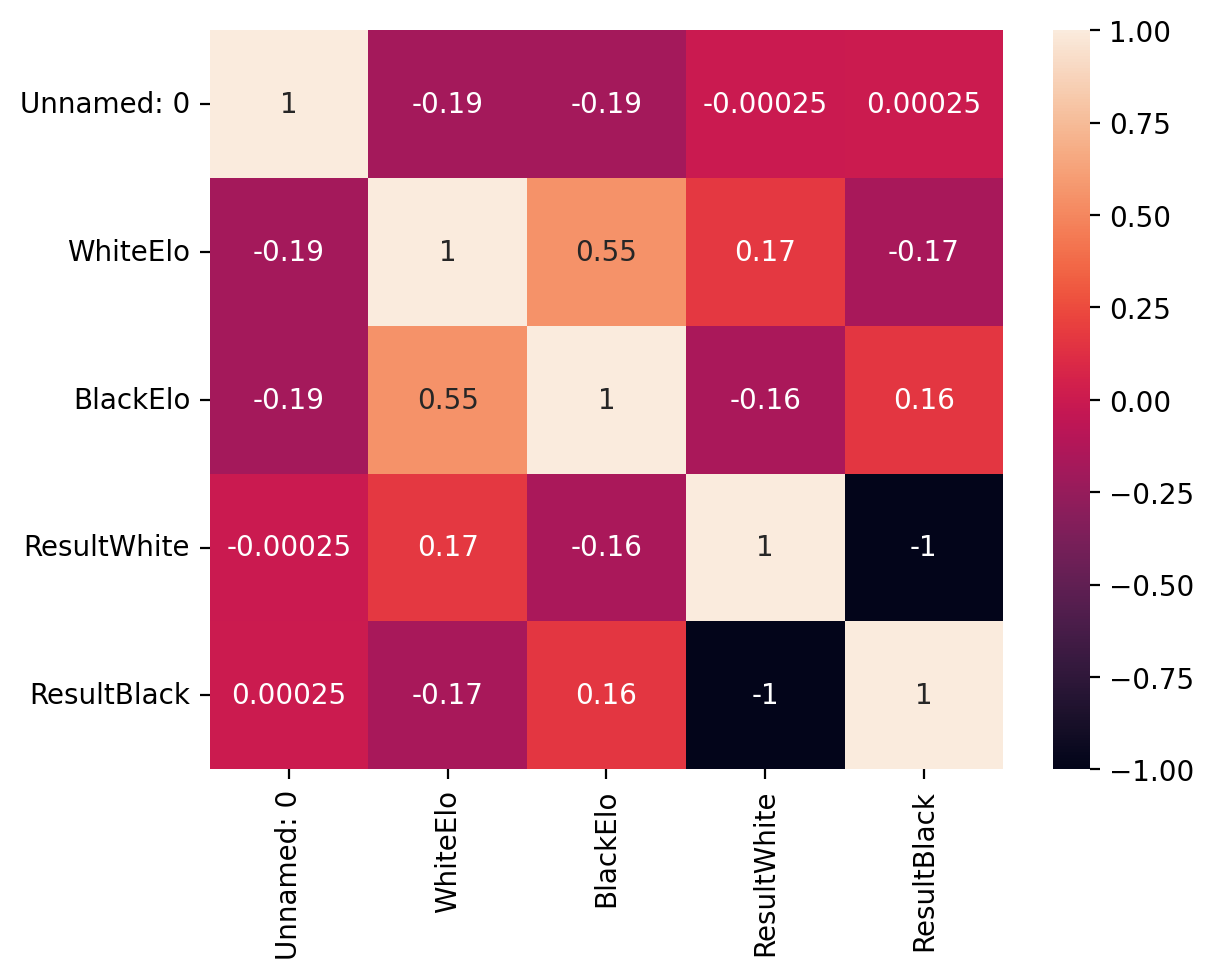

In [15]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

Correlação de Pearson entre duas variáveis (duas colunas de dados ou duas pandas' Series):

fonte: https://www.statology.org/correlation-test-in-python/

In [16]:
from scipy.stats.stats import pearsonr

x = df['WhiteElo']
y = df['BlackElo']

#calculation correlation coefficient and p-value between x and y
pearsonr(x, y)


C:\Users\davib\AppData\Local\Temp\ipykernel_18220\464384527.py:1: DeprecationWarning: Please import `pearsonr` from the `scipy.stats` namespace; the `scipy.stats.stats` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.stats.stats import pearsonr


PearsonRResult(statistic=np.float64(0.5505886311655955), pvalue=np.float64(0.0))

# Correlação de Spearman

A correlação de Spearman é utilizada para variáveis que NÃO seguem uma distribuição normal.
Inclusive, pode ser utilizado para variáveis ordinais.

In [17]:
df.corr('spearman', numeric_only=True)

,Unnamed: 0,WhiteElo,BlackElo,ResultWhite,ResultBlack
Unnamed: 0,1.000000,-0.221665,-0.221513,0.000025,-0.000025
WhiteElo,-0.221665,1.000000,0.726598,0.148461,-0.148461
BlackElo,-0.221513,0.726598,1.000000,-0.143276,0.143276
ResultWhite,0.000025,0.148461,-0.143276,1.000000,-1.000000
ResultBlack,-0.000025,-0.148461,0.143276,-1.000000,1.000000


-Mapa de calor: é possível visualizar as correlações em um mapa de calor utilizando a biblioteca Seaborn (sns).

<Axes: >

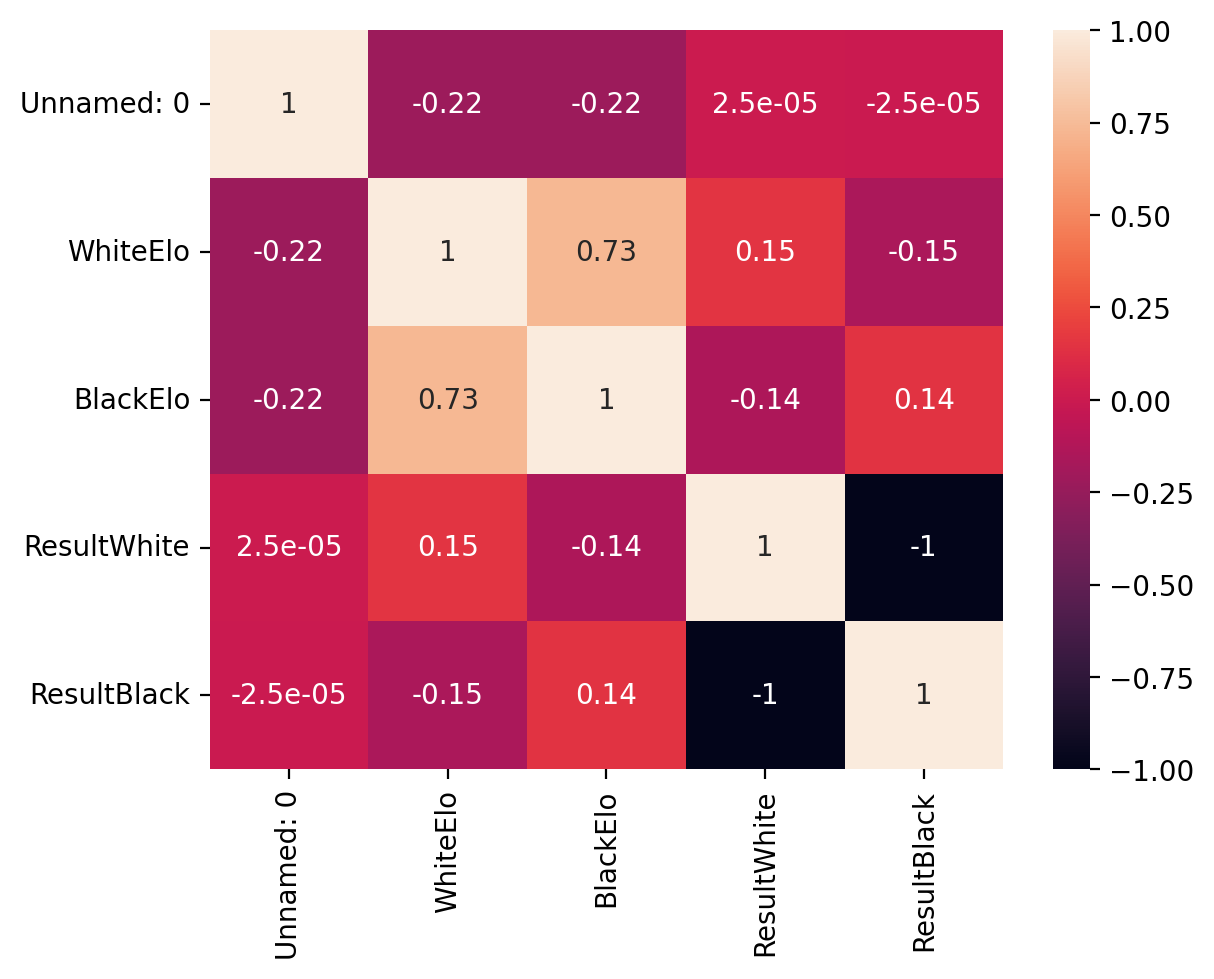

In [18]:
sns.heatmap(df.corr('spearman', numeric_only=True), annot=True)

# APLICAÇÃO DE MACHINE LEARNING

Agora Após algumas parametrizações será aplicado alguns testes.

In [19]:
pip install pandas numpy scikit-learn matplotlib seaborn plotly xgboost lightgbm catboost optuna 


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [20]:
import pandas as pd
import numpy as np
import math
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [21]:

# Conversão de tipos de dados
df['Date'] = pd.to_datetime(df['Date'])
df['EndTime'] = pd.to_datetime(df['EndTime'])

# Criação de features derivadas
df['GameDuration'] = ((df['EndTime'] - df['Date']).dt.total_seconds() / 60).fillna(0)
df['EloDiff'] = abs((df['WhiteElo'] - df['BlackElo']).fillna(0))
df['AvgElo'] = ((df['WhiteElo'] + df['BlackElo']) / 2).fillna(0)

# Extração do tempo de controle
df['BaseTime'] = df['TimeControl'].str.extract('(\d+)').astype(float).fillna(0)
df['Increment'] = df['TimeControl'].str.extract('\+(\d+)').astype(float).fillna(0)

# Codificação de variáveis categóricas
le = LabelEncoder()
df['White_encoded'] = le.fit_transform(df['White'])
df['Black_encoded'] = le.fit_transform(df['Black'])
df['ECO_encoded'] = le.fit_transform(df['ECO'])

# Codificação do resultado
result_map = {'1-0': 2, '0-1': 0, '1/2-1/2': 1}
df['Result_encoded'] = df['Result'].map(result_map)


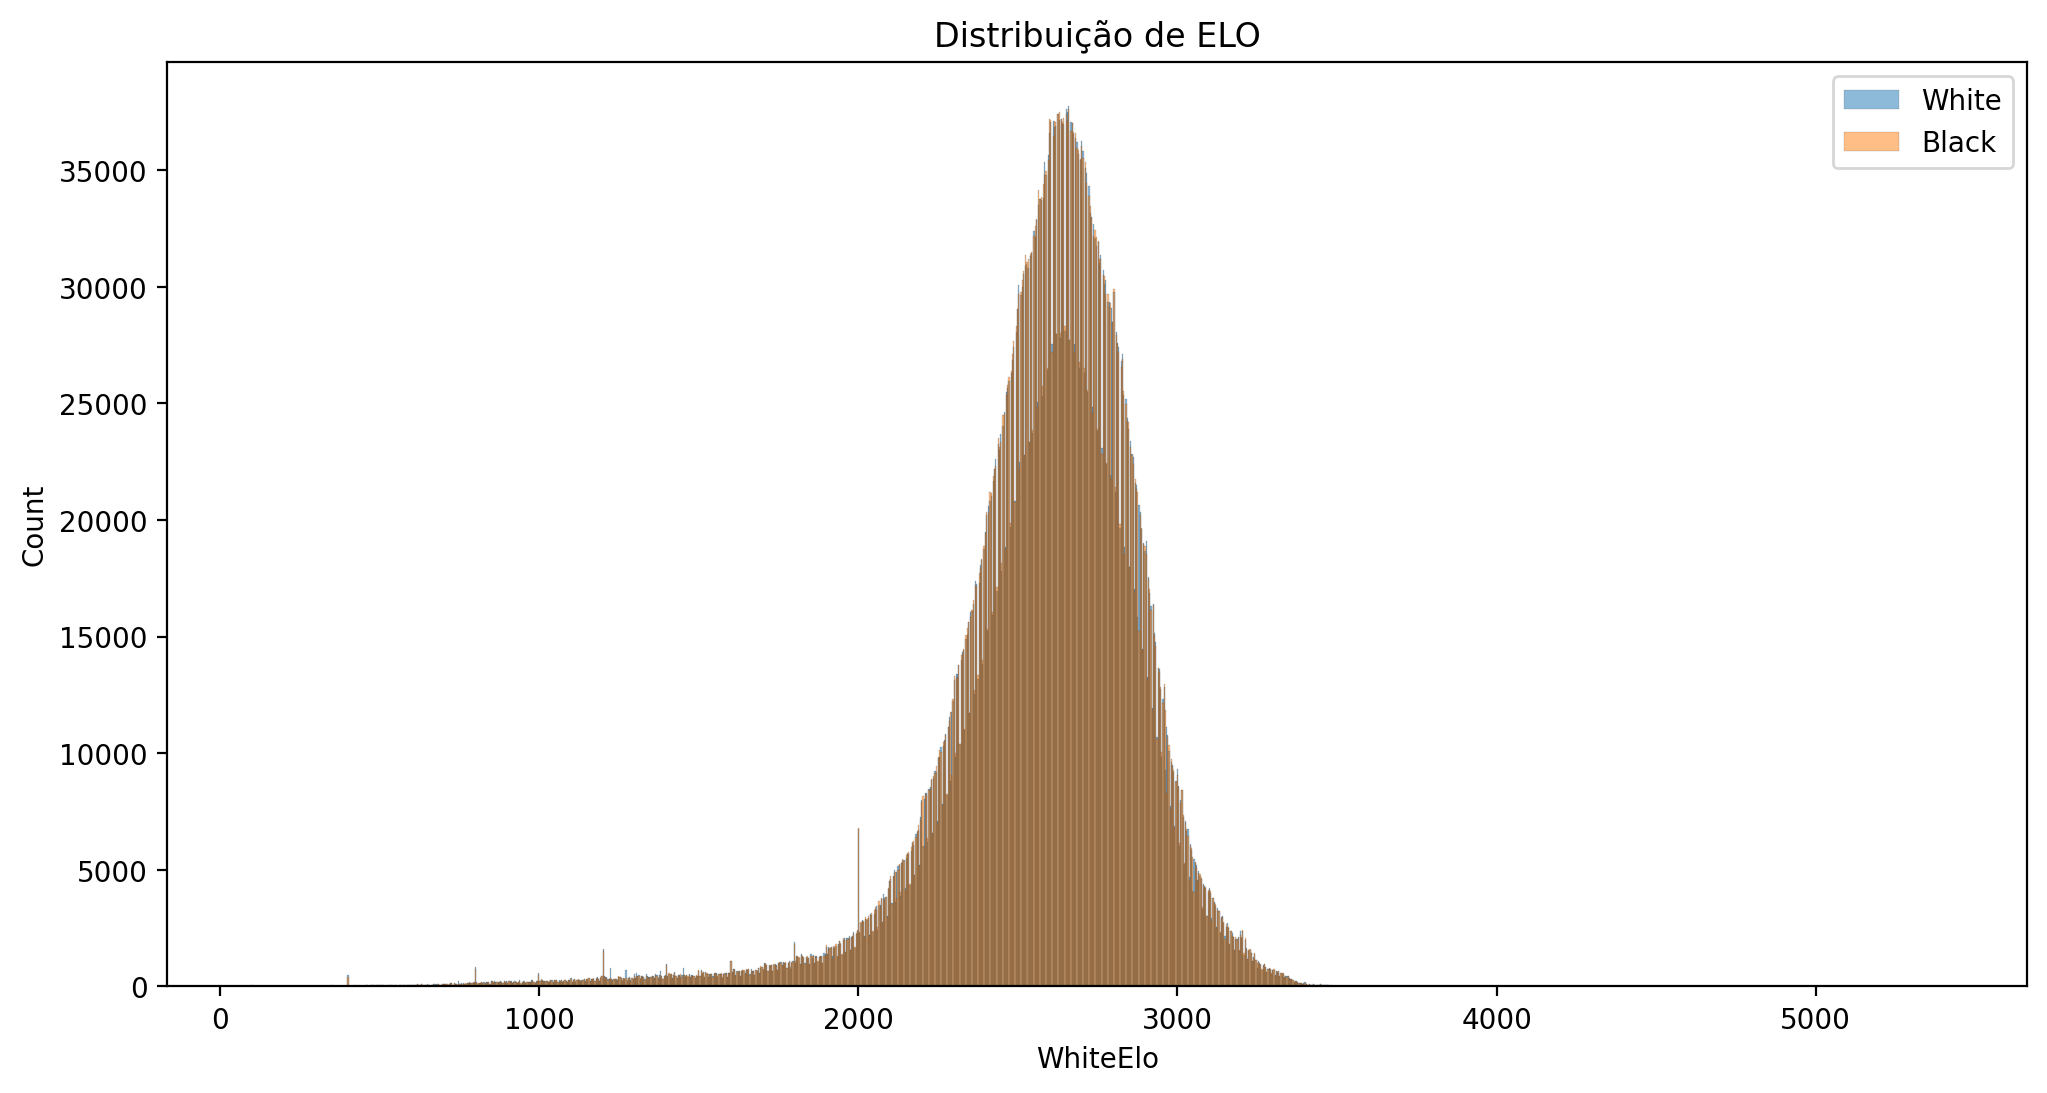

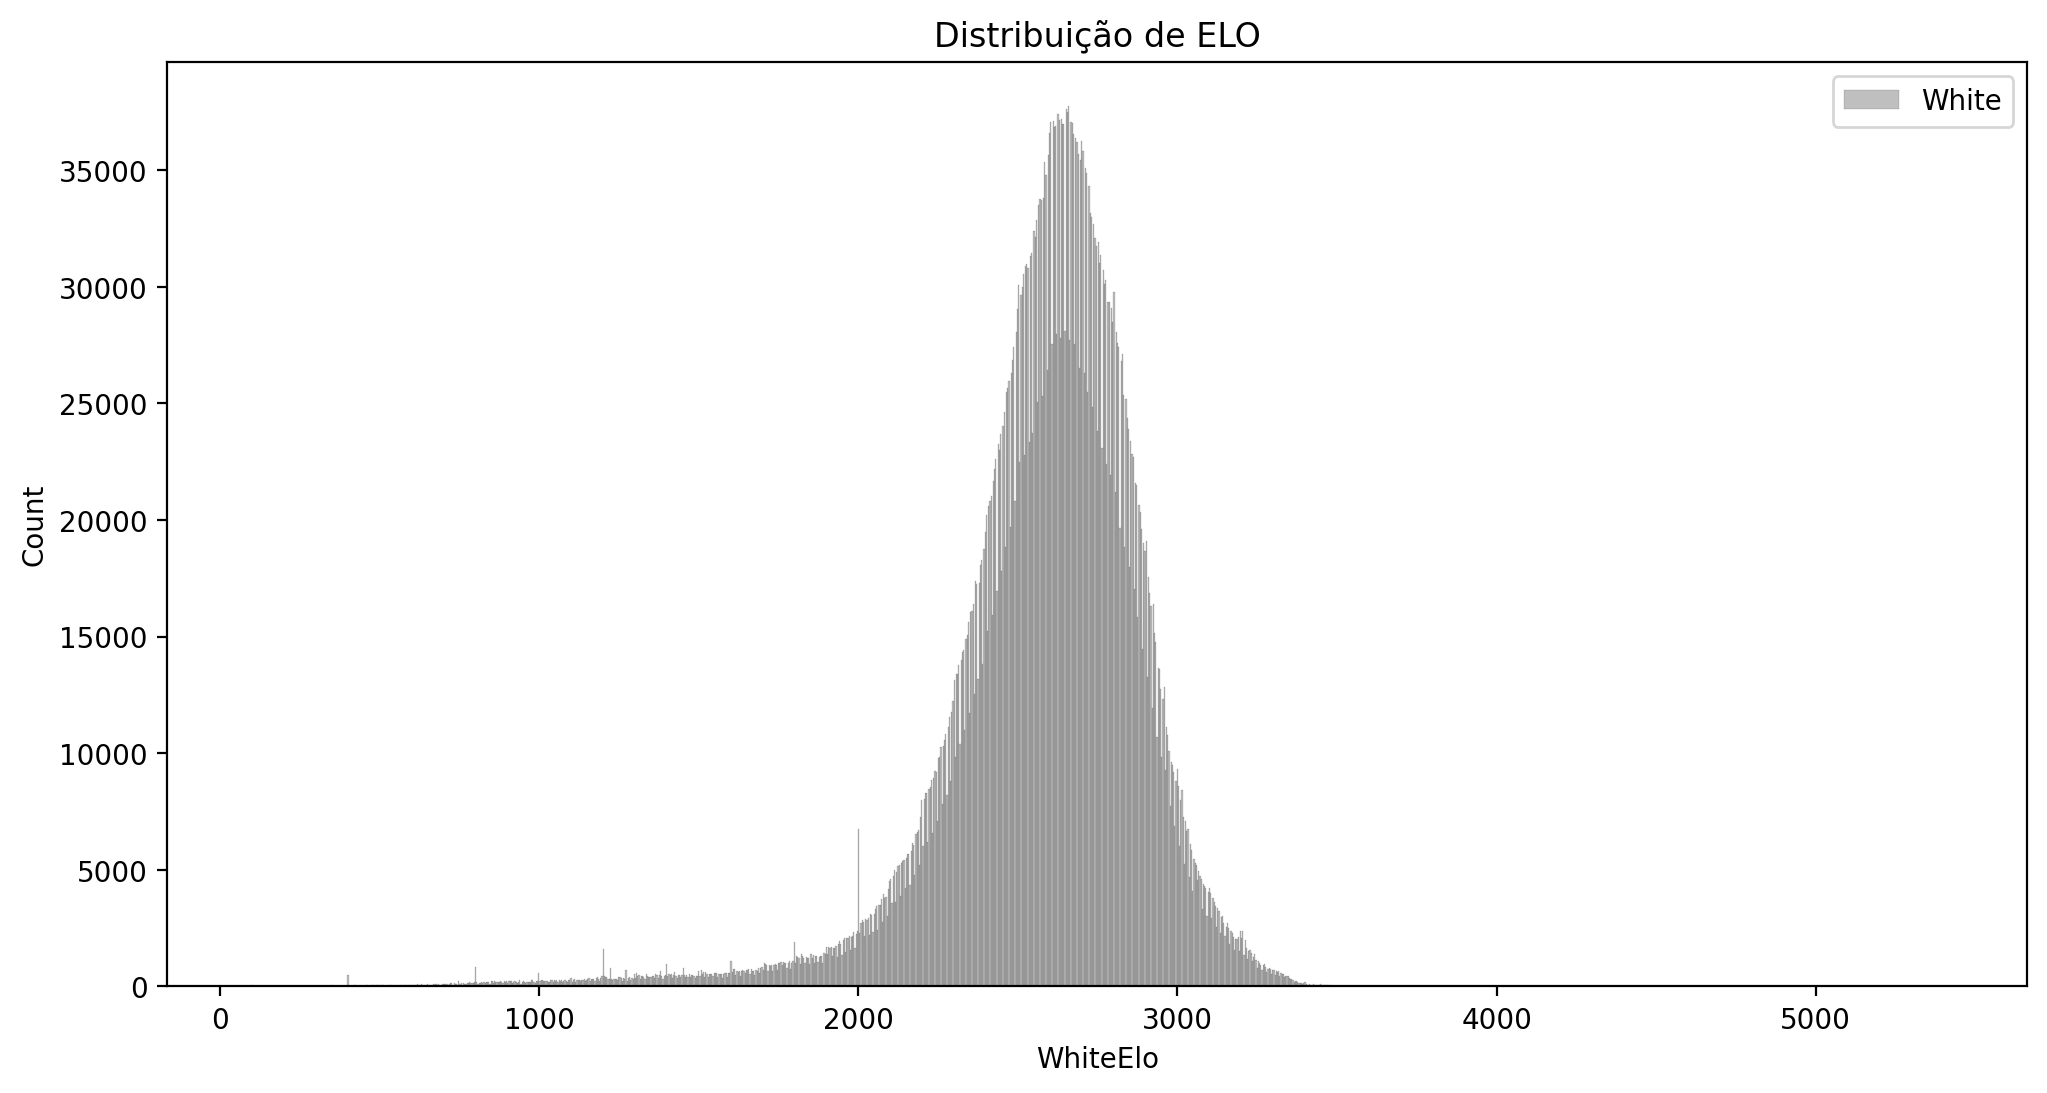

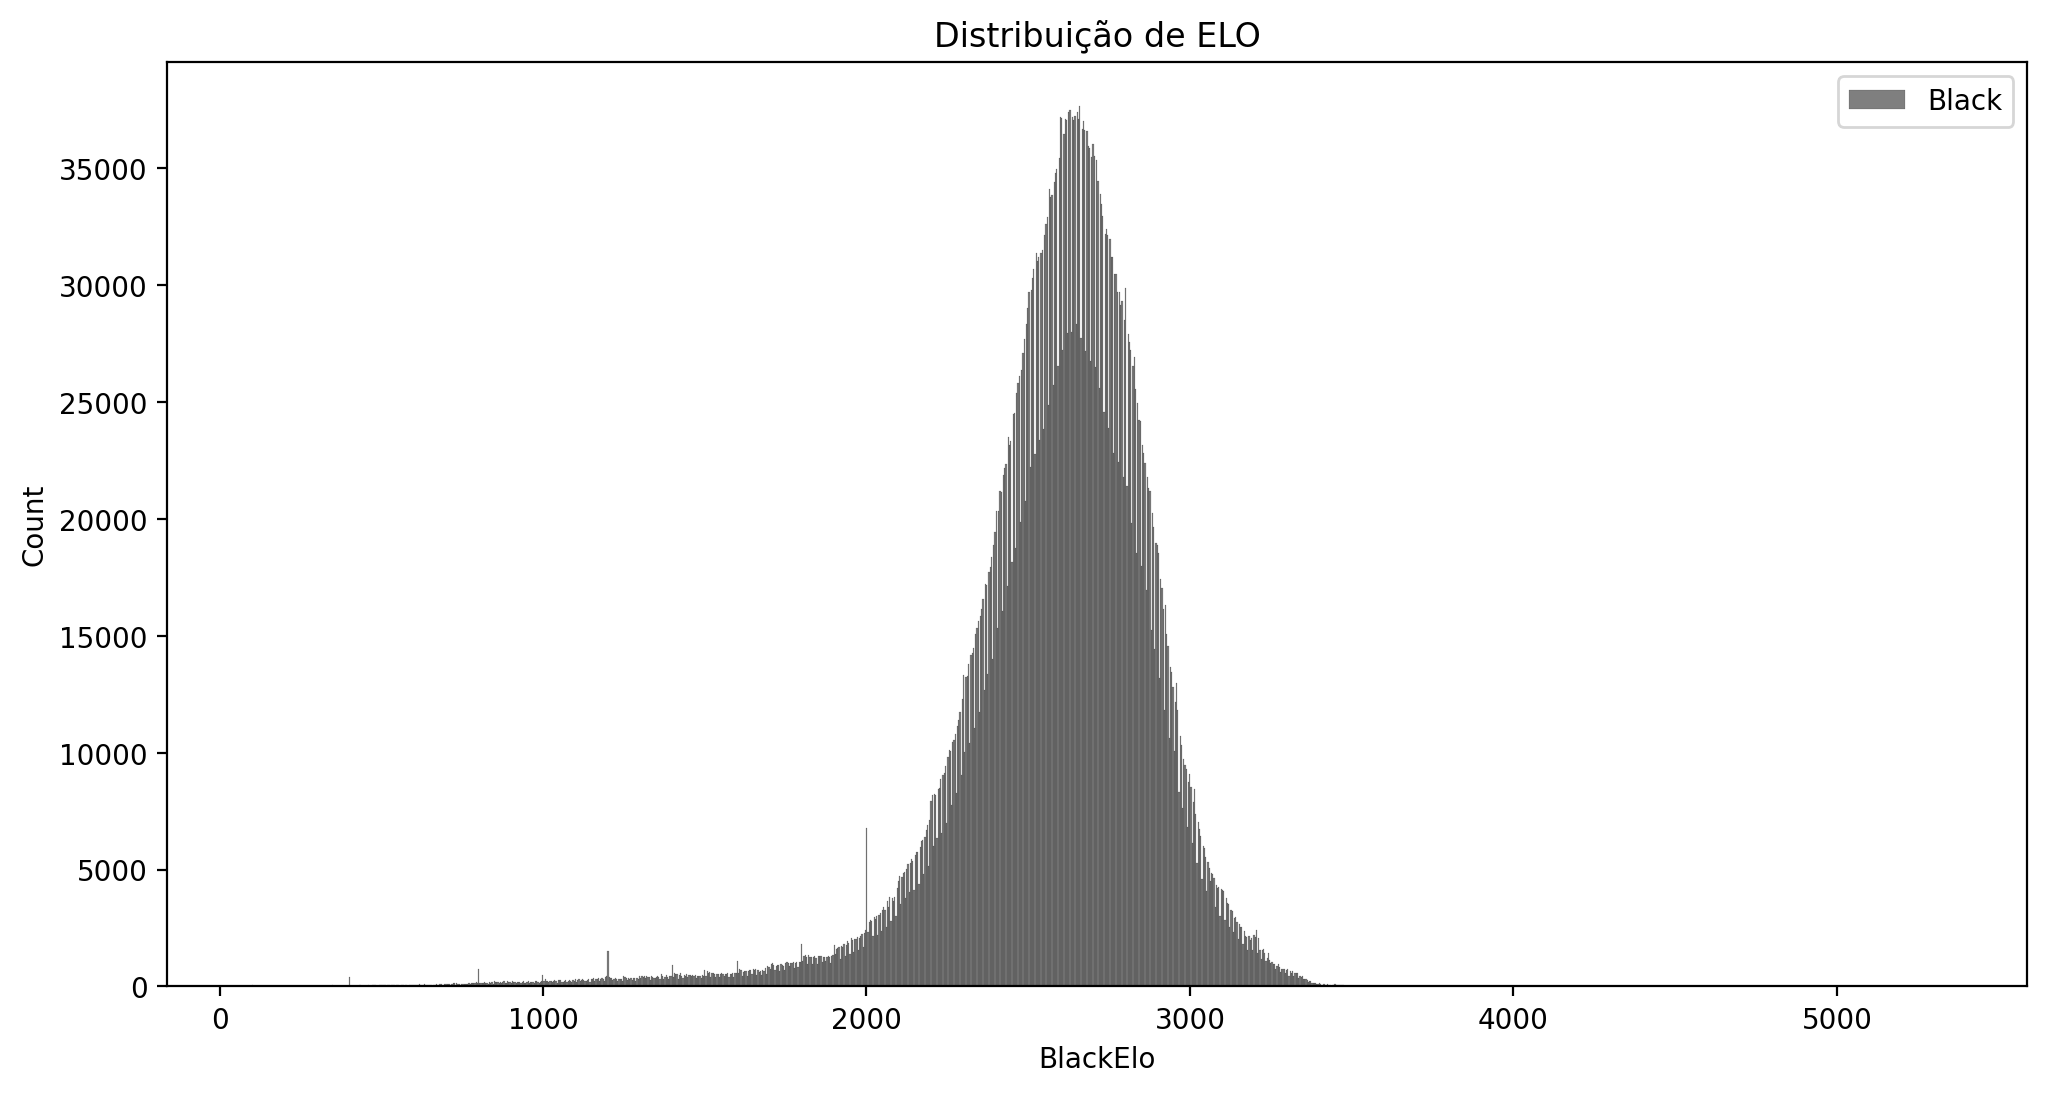

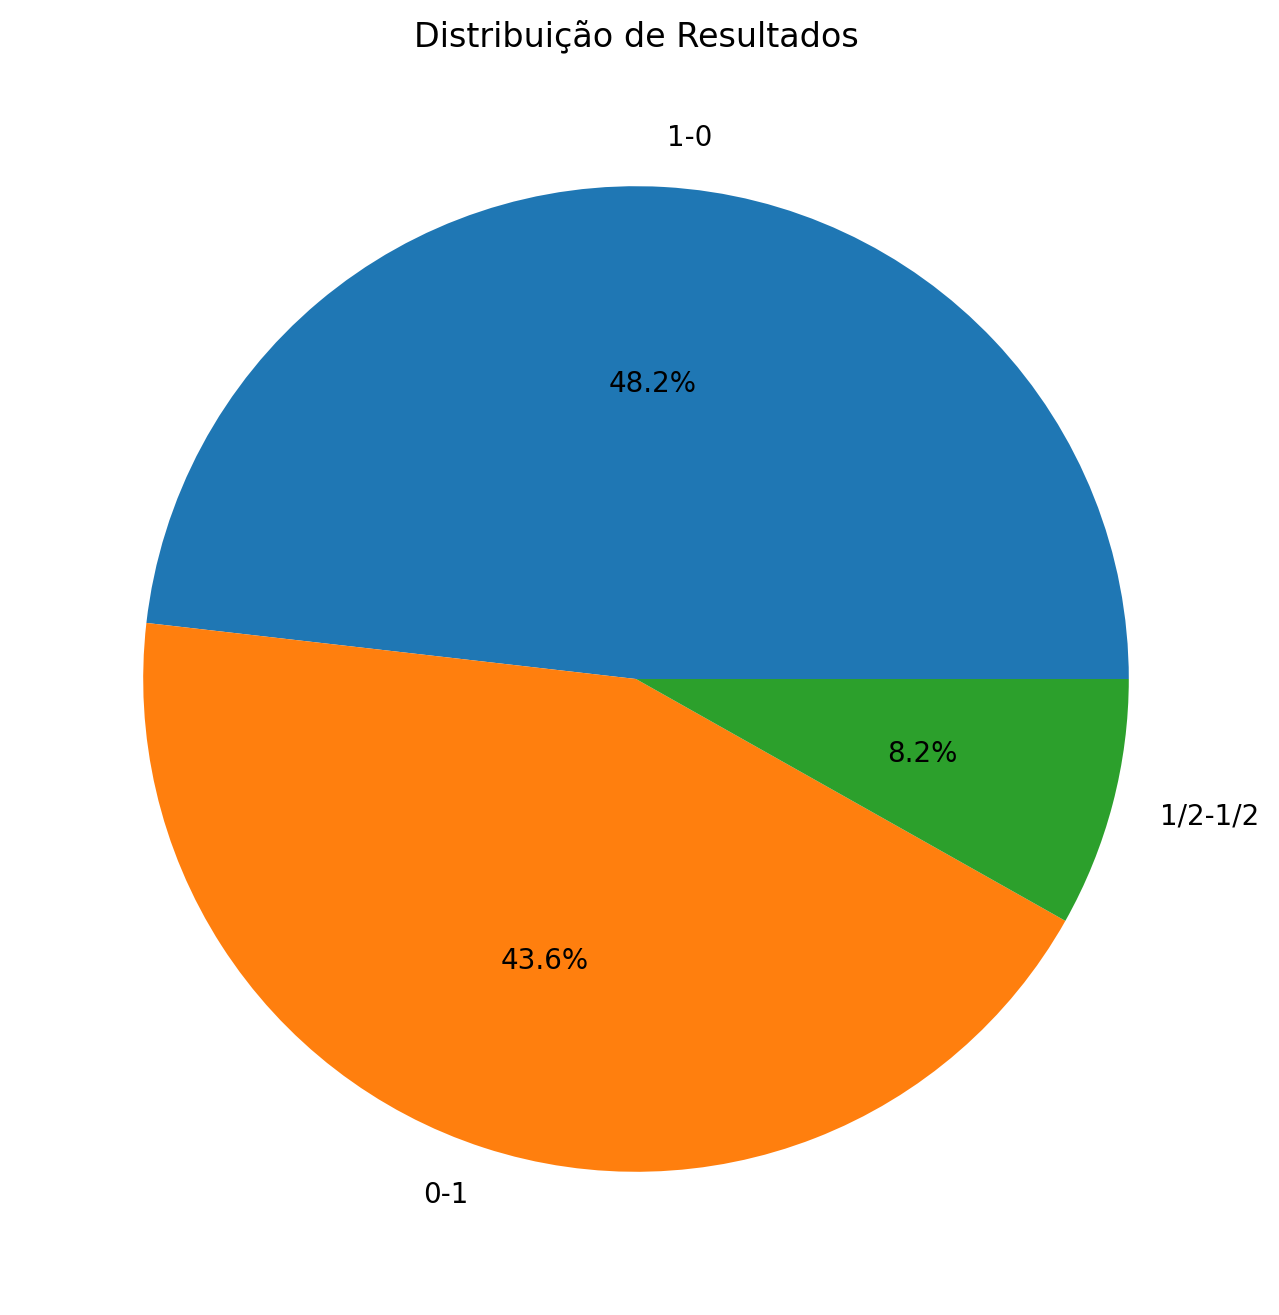

In [22]:

plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='WhiteElo', label='White', alpha=0.5)
sns.histplot(data=df, x='BlackElo', label='Black', alpha=0.5)
plt.title('Distribuição de ELO')
plt.legend()
plt.show()

plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='WhiteElo', label='White', alpha=0.5, color="Gray")
plt.title('Distribuição de ELO')
plt.legend()
plt.show()

plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='BlackElo', label='Black', alpha=0.5, color="Black")
plt.title('Distribuição de ELO')
plt.legend()
plt.show()

win_rates = df['Result'].value_counts(normalize=True)
plt.figure(figsize=(8, 8))
plt.pie(win_rates, labels=win_rates.index, autopct='%1.1f%%')
plt.title('Distribuição de Resultados')
plt.show()


In [23]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import train_test_split


def train_classification_model(df):
    # Corrigir a coluna alvo
    df['Result_str'] = df['Result'].map({
        '1-0': 'white_win',
        '0-1': 'black_win',
        '1/2-1/2': 'draw'
    })

    # Codificar o target como rótulos inteiros (necessário para classificadores)
    le_result = LabelEncoder()
    df['Result_encoded'] = le_result.fit_transform(df['Result_str'])

    # Preparação das features
    features = ['WhiteElo', 'BlackElo', 'EloDiff', 'AvgElo', 'BaseTime', 'Increment', 'ECO_encoded']
    X = df[features]
    y = df['Result_encoded']  # Agora categórico corretamente

    # Divisão dos dados
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Normalização
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Modelos de classificação
    models = {
        "RandomForest": RandomForestClassifier(n_estimators=100),
        "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss'),
        "LightGBM": LGBMClassifier(),
        "CatBoost": CatBoostClassifier(verbose=0),
        "LogisticRegression": LogisticRegression(multi_class='multinomial', max_iter=1000),
        "KNN": KNeighborsClassifier()
    }

    results = {}
    for name, model in models.items():
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        score = model.score(X_test_scaled, y_test)
        results[name] = score

        print(f"\n=== {name} ===")
        print(f"Acurácia: {score:.4f}")
        print("Relatório de Classificação:")
        print(classification_report(y_test, y_pred, target_names=le_result.classes_))

    return models, scaler

# Supondo que você já tenha carregado o DataFrame df previamente
# Exemplo: df = pd.read_csv("seu_arquivo.csv")
# Chamada da função
# train_classification_model(df)


train_classification_model(df)


=== RandomForest ===
Acurácia: 0.5987
Relatório de Classificação:
              precision    recall  f1-score   support

   black_win       0.60      0.62      0.61    471824
        draw       0.17      0.09      0.12     88215
   white_win       0.63      0.66      0.65    519890

    accuracy                           0.60   1079929
   macro avg       0.47      0.46      0.46   1079929
weighted avg       0.58      0.60      0.59   1079929


=== XGBoost ===
Acurácia: 0.6489
Relatório de Classificação:
              precision    recall  f1-score   support

   black_win       0.64      0.66      0.65    471824
        draw       0.54      0.01      0.02     88215
   white_win       0.65      0.74      0.70    519890

    accuracy                           0.65   1079929
   macro avg       0.61      0.47      0.46   1079929
weighted avg       0.64      0.65      0.62   1079929

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.020870 seconds.
You c

({'RandomForest': RandomForestClassifier(),
  'XGBoost': XGBClassifier(base_score=None, booster=None, callbacks=None,
                colsample_bylevel=None, colsample_bynode=None,
                colsample_bytree=None, device=None, early_stopping_rounds=None,
                enable_categorical=False, eval_metric='mlogloss',
                feature_types=None, feature_weights=None, gamma=None,
                grow_policy=None, importance_type=None,
                interaction_constraints=None, learning_rate=None, max_bin=None,
                max_cat_threshold=None, max_cat_to_onehot=None,
                max_delta_step=None, max_depth=None, max_leaves=None,
                min_child_weight=None, missing=nan, monotone_constraints=None,
                multi_strategy=None, n_estimators=None, n_jobs=None,
                num_parallel_tree=None, ...),
  'LightGBM': LGBMClassifier(),
  'CatBoost': <catboost.core.CatBoostClassifier at 0x18c10305fd0>,
  'LogisticRegression': LogisticRegressi

In [29]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import train_test_split


def train_classification_model(df):
    # Corrigir a coluna alvo
    df['Result_str'] = df['Result'].map({
        '1-0': 'white_win',
        '0-1': 'black_win',
        '1/2-1/2': 'draw'
    })

    # Codificar o target como rótulos inteiros (necessário para classificadores)
    le_result = LabelEncoder()
    df['Result_encoded'] = le_result.fit_transform(df['Result_str'])

    # Preparação das features
    features = ['WhiteElo', 'BlackElo', 'EloDiff', 'AvgElo', 'BaseTime', 'Increment', 'ECO_encoded']
    X = df[features]
    y = df['Result_encoded']  # Agora categórico corretamente

    # Divisão dos dados
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Normalização
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Modelos de classificação
    models = {
        "LightGBM": LGBMClassifier(),
        "CatBoost": CatBoostClassifier(verbose=0),
        "LogisticRegression": LogisticRegression(multi_class='multinomial', max_iter=1000),
        "KNN": KNeighborsClassifier()
    }

    results = {}
    for name, model in models.items():
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        score = model.score(X_test_scaled, y_test)
        results[name] = score

        print(f"\n=== {name} ===")
        print(f"Acurácia: {score:.4f}")
        print("Relatório de Classificação:")
        print(classification_report(y_test, y_pred, target_names=le_result.classes_))

    return models, scaler

# Supondo que você já tenha carregado o DataFrame df previamente
# Exemplo: df = pd.read_csv("seu_arquivo.csv")
# Chamada da função
# train_classification_model(df)


train_classification_model(df)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.021144 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1324
[LightGBM] [Info] Number of data points in the train set: 4319716, number of used features: 7
[LightGBM] [Info] Start training from score -0.829205
[LightGBM] [Info] Start training from score -2.505412
[LightGBM] [Info] Start training from score -0.729890

=== LightGBM ===
Acurácia: 0.6487
Relatório de Classificação:
              precision    recall  f1-score   support

   black_win       0.64      0.67      0.66    471824
        draw       0.57      0.01      0.02     88215
   white_win       0.66      0.74      0.69    519890

    accuracy                           0.65   1079929
   macro avg       0.62      0.47      0.46   1079929
weighted avg       0.64      0.65      0.62   1079929


=== CatBoost ===
Acurácia: 0.6490
Relat

({'LightGBM': LGBMClassifier(),
  'CatBoost': <catboost.core.CatBoostClassifier at 0x18c1051c080>,
  'LogisticRegression': LogisticRegression(max_iter=1000, multi_class='multinomial'),
  'KNN': KNeighborsClassifier()},
 StandardScaler())

In [24]:
def plot_feature_importance(model, features):
    importance = model.feature_importances_
    feat_importance = pd.DataFrame({
        'Feature': features,
        'Importance': importance
    }).sort_values('Importance', ascending=False)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(data=feat_importance, x='Importance', y='Feature')
    plt.title('Importância das Features')
    plt.show()


In [25]:
import optuna

def optimize_model(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_loguniform('learning_rate', 1e-3, 1.0)
    }
    
    model = XGBClassifier(**params)
    score = cross_val_score(model, X_train_scaled, y_train, cv=5).mean()
    return score

def run_optimization():
    study = optuna.create_study(direction='maximize')
    study.optimize(optimize_model, n_trials=100)
    return study.best_params


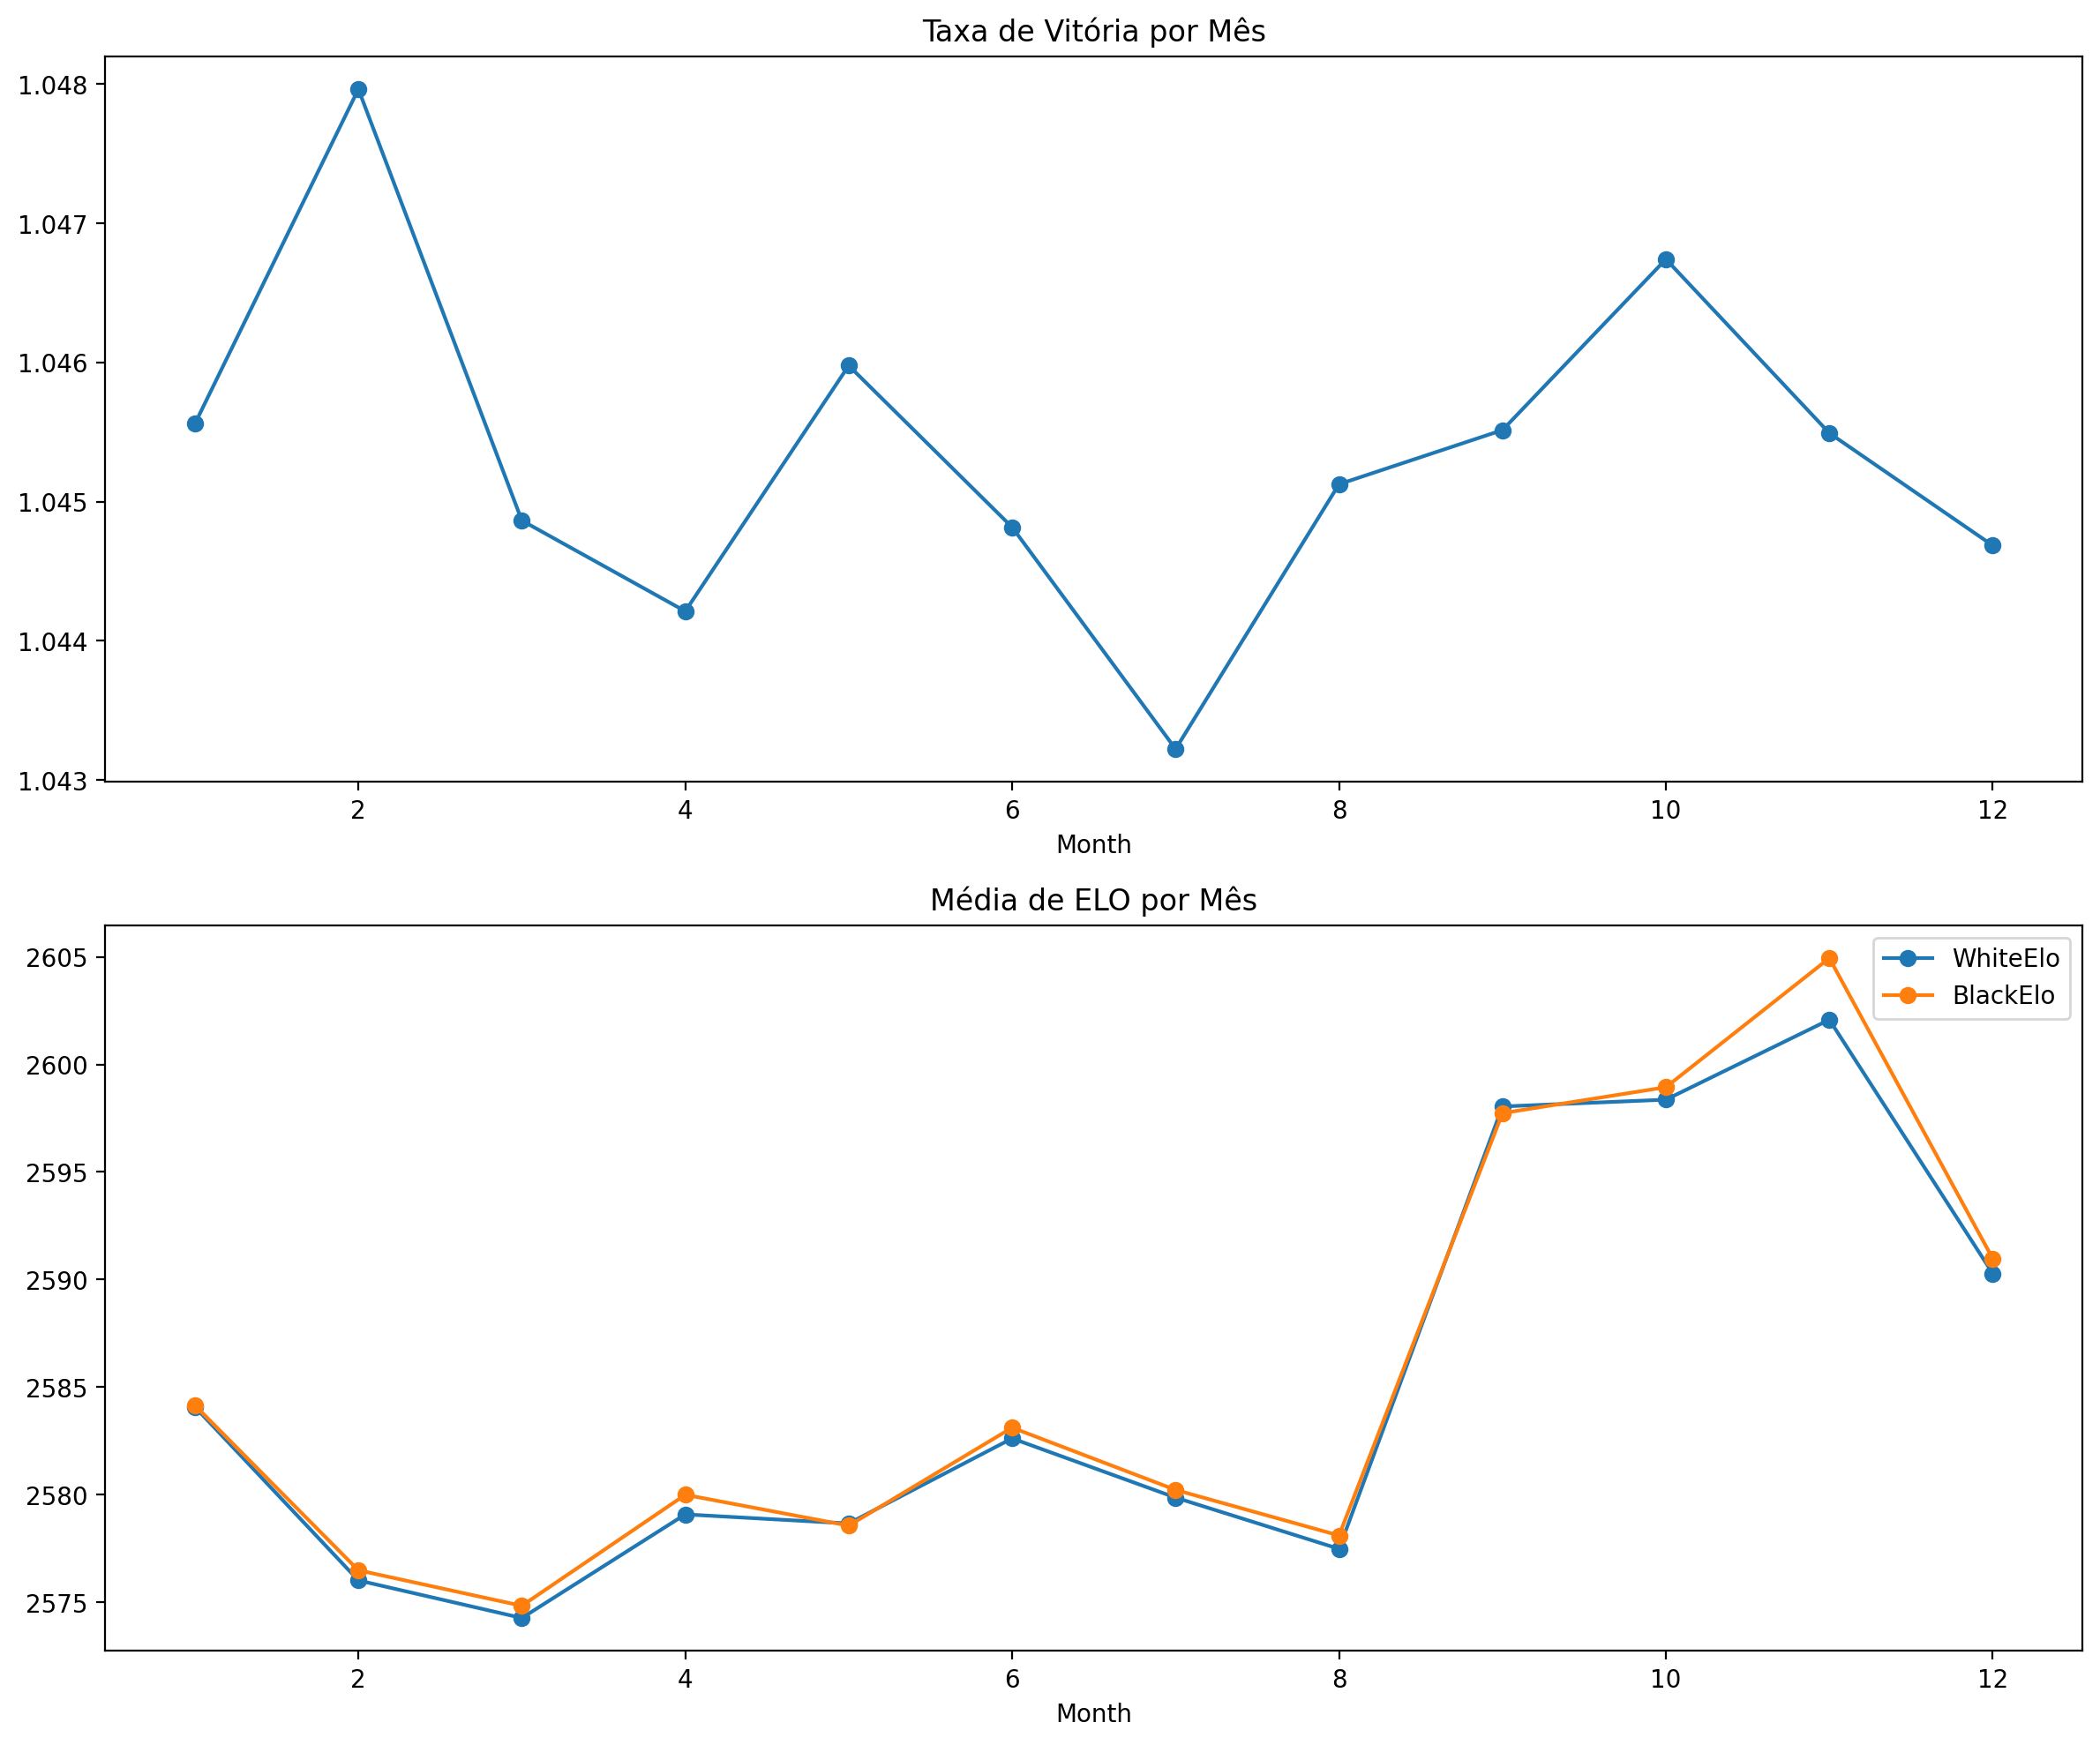

In [26]:

# Análise por mês
df['Month'] = df['Date'].dt.month
monthly_stats = df.groupby('Month').agg({
    'Result_encoded': 'mean',
    'WhiteElo': 'mean',
    'BlackElo': 'mean'
})

# Visualização
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

monthly_stats['Result_encoded'].plot(
    ax=axes[0], kind='line', marker='o'
)
axes[0].set_title('Taxa de Vitória por Mês')

monthly_stats[['WhiteElo', 'BlackElo']].plot(
    ax=axes[1], kind='line', marker='o'
)
axes[1].set_title('Média de ELO por Mês')

plt.tight_layout()
plt.show()


In [28]:
pip install xgboost lightgbm catboost scikit-learn


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
